# DeepLOB with feature engineering:
- Order imbalance: measures the overall buying versus selling pressure in the order book by comparing total bid volume against total ask volume.
- Queue imbalance: measures the buying versus selling pressure at the best bid and ask levels by comparing the top-of-book bid volume against ask volume.

In [1]:
import os
if not os.path.isfile('data.zip'):
    !wget https://raw.githubusercontent.com/zcakhaa/DeepLOB-Deep-Convolutional-Neural-Networks-for-Limit-Order-Books/master/data/data.zip
    !unzip -n data.zip
    print('data downloaded.')
else:
    print('data already existed.')

--2026-05-14 15:55:53--  https://raw.githubusercontent.com/zcakhaa/DeepLOB-Deep-Convolutional-Neural-Networks-for-Limit-Order-Books/master/data/data.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 56278154 (54M) [application/zip]
Saving to: ‘data.zip’

data.zip            100%[===================>]  53.67M  79.2MB/s    in 0.7s    

2026-05-14 15:55:55 (79.2 MB/s) - ‘data.zip’ saved [56278154/56278154]

Archive:  data.zip
  inflating: Test_Dst_NoAuction_DecPre_CF_7.txt  
  inflating: Test_Dst_NoAuction_DecPre_CF_9.txt  
  inflating: Test_Dst_NoAuction_DecPre_CF_8.txt  
  inflating: Train_Dst_NoAuction_DecPre_CF_7.txt  
data downloaded.


In [2]:
# load packages
!pip install torchinfo
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report

import torch
import torch.nn.functional as F
from torch.utils import data
from torchinfo import summary
import torch.nn as nn
import torch.optim as optim
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.33)
# N, D = X_train.shape

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [4]:
class LOBDataset(torch.utils.data.Dataset):
    """
    Memory-efficient FI-2010 dataset with
    imbalance-based microstructure features.
    """

    def __init__(
        self,
        data,
        k=4,
        num_classes=3,
        T=100,
    ):

        self.T = T
        self.k = k
        self.num_classes = num_classes

        # ======================================
        # Raw LOB Features
        # ======================================

        lob = data[:40].T.astype(np.float32)

        # Shape:
        # (timesteps, 40)

        # ======================================
        # Extract Volumes
        # ======================================

        ask_volumes = lob[:, 1::4]
        bid_volumes = lob[:, 3::4]

        # ======================================
        # Order Imbalance
        # ======================================

        total_bid_volume = np.sum(
            bid_volumes,
            axis=1
        )

        total_ask_volume = np.sum(
            ask_volumes,
            axis=1
        )

        imbalance = (
            (total_bid_volume - total_ask_volume)
            / (total_bid_volume + total_ask_volume + 1e-8)
        ).reshape(-1, 1)

        # ======================================
        # Queue Imbalance
        # ======================================

        queue_imbalance = (
            (bid_volumes[:, 0] - ask_volumes[:, 0])
            / (bid_volumes[:, 0] + ask_volumes[:, 0] + 1e-8)
        ).reshape(-1, 1)

        # ======================================
        # Final Features
        # ======================================

        engineered_features = np.concatenate(
            [
                imbalance,
                queue_imbalance,
            ],
            axis=1
        ).astype(np.float32)

        self.x = np.concatenate(
            [
                lob,
                engineered_features,
            ],
            axis=1
        ).astype(np.float32)

        # Final shape:
        # (timesteps, 42)

        # ======================================
        # Labels
        # ======================================

        self.y = (
            data[144 + k - 1]
            .astype(np.int64)
            - 1
        )

    def __len__(self):

        return len(self.x) - self.T

    def __getitem__(self, idx):

        # ======================================
        # Rolling Window
        # ======================================

        x_window = self.x[
            idx : idx + self.T
        ]

        # Shape:
        # (T, 42)

        y_label = self.y[
            idx + self.T - 1
        ]

        # ======================================
        # Tensor Conversion
        # ======================================

        x_tensor = torch.tensor(
            x_window,
            dtype=torch.float32
        ).unsqueeze(0)

        # Final shape:
        # (1, T, 42)

        y_tensor = torch.tensor(
            y_label,
            dtype=torch.long
        )

        return x_tensor, y_tensor

# Data preparation

We used no auction dataset that is normalised by decimal precision approach in their work. The first seven days are training data and the last three days are testing data. A validation set (20%) from the training set is used to monitor the overfitting behaviours.  

The first 40 columns of the FI-2010 dataset are 10 levels ask and bid information for a limit order book and we only use these 40 features in our network. The last 5 columns of the FI-2010 dataset are the labels with different prediction horizons.

In [5]:
import numpy as np
from pathlib import Path

# ======================================
# Memory-Efficient Loader
# ======================================

def load_dataset(file_path):
    """
    Load dataset using float32 instead of float64.

    This cuts memory usage roughly in half.
    """

    return np.loadtxt(
        file_path,
        dtype=np.float32
    )


# ======================================
# Load Train + Validation
# ======================================

dec_data = load_dataset(
    "Train_Dst_NoAuction_DecPre_CF_7.txt"
)

# Split along time dimension
split_idx = int(dec_data.shape[1] * 0.8)

dec_train = dec_data[:, :split_idx]
dec_val = dec_data[:, split_idx:]

# Free unused memory immediately
del dec_data

# ======================================
# Load Test Sets
# ======================================

test_files = [
    "Test_Dst_NoAuction_DecPre_CF_7.txt",
    "Test_Dst_NoAuction_DecPre_CF_8.txt",
    "Test_Dst_NoAuction_DecPre_CF_9.txt",
]

test_arrays = []

for file_name in test_files:

    arr = load_dataset(
        file_name
    )

    test_arrays.append(arr)

# Concatenate across time dimension
dec_test = np.concatenate(
    test_arrays,
    axis=1
)

# Free temporary arrays
del test_arrays

# ======================================
# Final Shapes
# ======================================

print("Train:", dec_train.shape)
print("Validation:", dec_val.shape)
print("Test:", dec_test.shape)

# ======================================
# Memory Usage Check
# ======================================

total_gb = (
    dec_train.nbytes +
    dec_val.nbytes +
    dec_test.nbytes
) / (1024**3)

print(f"Approx RAM usage: {total_gb:.2f} GB")

Train: (149, 203800)
Validation: (149, 50950)
Test: (149, 139587)
Approx RAM usage: 0.22 GB


In [6]:
batch_size = 64

dataset_train = LOBDataset(
    data=dec_train,
    k=4,
    num_classes=3,
    T=100,
)

dataset_val = LOBDataset(
    data=dec_val,
    k=4,
    num_classes=3,
    T=100,
)

dataset_test = LOBDataset(
    data=dec_test,
    k=4,
    num_classes=3,
    T=100,
)

train_loader = torch.utils.data.DataLoader(
    dataset_train,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = torch.utils.data.DataLoader(
    dataset_val,
    batch_size=batch_size,
    shuffle=False,
)

test_loader = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=batch_size,
    shuffle=False,
)

print(len(dataset_train))

203700


In [7]:
tmp_loader = torch.utils.data.DataLoader(dataset=dataset_train, batch_size=1, shuffle=True)

for x, y in tmp_loader:
    print(x)
    print(y)
    print(x.shape, y.shape)
    break

tensor([[[[ 0.1259,  0.0223,  0.1257,  ...,  0.0202, -0.3227, -0.7630],
          [ 0.1259,  0.0223,  0.1257,  ...,  0.0202, -0.2240, -0.7630],
          [ 0.1259,  0.0223,  0.1257,  ...,  0.0202, -0.2504, -0.7630],
          ...,
          [ 0.1260,  0.0323,  0.1257,  ...,  0.0333,  0.0497, -0.2140],
          [ 0.1260,  0.0323,  0.1256,  ...,  0.0090, -0.0115, -0.5218],
          [ 0.1257,  0.0166,  0.1256,  ...,  0.0090,  0.0025,  0.2753]]]])
tensor([2])
torch.Size([1, 1, 100, 42]) torch.Size([1])


# Model Architecture

Please find the detailed discussion of our model architecture in our paper.

In [8]:
class deeplob(nn.Module):
    def __init__(self, y_len):
        super().__init__()
        self.y_len = y_len

        # convolution blocks
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(1,2), stride=(1,2)),
            nn.LeakyReLU(negative_slope=0.01),
#             nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1,2), stride=(1,2)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1,10)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )

        # inception moduels
        self.inp1 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(5,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp3 = nn.Sequential(
            nn.MaxPool2d((3, 1), stride=(1, 1), padding=(1, 0)),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )

        # lstm layers
        self.lstm = nn.LSTM(input_size=192, hidden_size=64, num_layers=1, batch_first=True)
        self.fc1 = nn.Linear(64, self.y_len)

    def forward(self, x):
        # h0: (number of hidden layers, batch size, hidden size)
        h0 = torch.zeros(1, x.size(0), 64).to(device)
        c0 = torch.zeros(1, x.size(0), 64).to(device)

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        x_inp1 = self.inp1(x)
        x_inp2 = self.inp2(x)
        x_inp3 = self.inp3(x)

        x = torch.cat((x_inp1, x_inp2, x_inp3), dim=1)

#         x = torch.transpose(x, 1, 2)
        x = x.permute(0, 2, 1, 3)
        x = torch.reshape(x, (-1, x.shape[1], x.shape[2]))

        x, _ = self.lstm(x, (h0, c0))
        x = x[:, -1, :]
        x = self.fc1(x)
        forecast_y = torch.softmax(x, dim=1)

        return forecast_y

In [9]:
model = deeplob(y_len = dataset_train.num_classes)
model.to(device)

deeplob(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(1, 2), stride=(1, 2))
    (1): LeakyReLU(negative_slope=0.01)
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 32, kernel_size=(4, 1), stride=(1, 1))
    (4): LeakyReLU(negative_slope=0.01)
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv2d(32, 32, kernel_size=(4, 1), stride=(1, 1))
    (7): LeakyReLU(negative_slope=0.01)
    (8): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(1, 2), stride=(1, 2))
    (1): Tanh()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 32, kernel_size=(4, 1), stride=(1, 1))
    (4): Tanh()
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv2d(32, 32, kernel_size=(4, 1), stride

In [10]:
summary(model, (1, 1, 100, 40))

Layer (type:depth-idx)                   Output Shape              Param #
deeplob                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 32, 94, 20]           --
│    └─Conv2d: 2-1                       [1, 32, 100, 20]          96
│    └─LeakyReLU: 2-2                    [1, 32, 100, 20]          --
│    └─BatchNorm2d: 2-3                  [1, 32, 100, 20]          64
│    └─Conv2d: 2-4                       [1, 32, 97, 20]           4,128
│    └─LeakyReLU: 2-5                    [1, 32, 97, 20]           --
│    └─BatchNorm2d: 2-6                  [1, 32, 97, 20]           64
│    └─Conv2d: 2-7                       [1, 32, 94, 20]           4,128
│    └─LeakyReLU: 2-8                    [1, 32, 94, 20]           --
│    └─BatchNorm2d: 2-9                  [1, 32, 94, 20]           64
├─Sequential: 1-2                        [1, 32, 88, 10]           --
│    └─Conv2d: 2-10                      [1, 32, 94, 10]           2,080
│    └

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# Model Training


In [12]:
from datetime import datetime
from tqdm import tqdm

import numpy as np
import torch

# ======================================
# Optimized Training Loop
# ======================================

def train_model(
    model,
    criterion,
    optimizer,
    train_loader,
    val_loader,
    epochs,
    device,
    scheduler=None,
    save_path="./best_val_featureengmodel_pytorch.pt",
):

    # ----------------------------------
    # Mixed Precision
    # ----------------------------------

    scaler = torch.cuda.amp.GradScaler()

    # ----------------------------------
    # Loss Tracking
    # ----------------------------------

    train_losses = np.zeros(epochs)
    val_losses = np.zeros(epochs)

    best_val_loss = np.inf
    best_val_epoch = 0

    # ==================================
    # Training Loop
    # ==================================

    for epoch in tqdm(range(epochs)):

        model.train()

        epoch_start_time = datetime.now()

        running_train_loss = 0.0

        # ==============================
        # Training Step
        # ==============================

        for inputs, targets in train_loader:

            # --------------------------
            # Move data to GPU
            # --------------------------

            inputs = inputs.to(
                device,
                non_blocking=True
            )

            targets = targets.to(
                device,
                non_blocking=True
            )

            # --------------------------
            # Zero gradients
            # --------------------------

            optimizer.zero_grad()

            # --------------------------
            # Mixed Precision Forward
            # --------------------------

            with torch.cuda.amp.autocast():

                outputs = model(inputs)

                loss = criterion(
                    outputs,
                    targets
                )

            # --------------------------
            # Backpropagation
            # --------------------------

            scaler.scale(loss).backward()

            # --------------------------
            # Gradient Clipping
            # --------------------------

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            # --------------------------
            # Optimizer Step
            # --------------------------

            scaler.step(optimizer)

            scaler.update()

            running_train_loss += loss.item()

        # Average train loss
        avg_train_loss = (
            running_train_loss / len(train_loader)
        )

        # ==============================
        # Validation Step
        # ==============================

        model.eval()

        running_val_loss = 0.0

        correct_predictions = 0
        total_predictions = 0

        with torch.no_grad():

            for inputs, targets in val_loader:

                inputs = inputs.to(
                    device,
                    non_blocking=True
                )

                targets = targets.to(
                    device,
                    non_blocking=True
                )

                # ----------------------
                # Mixed Precision
                # ----------------------

                with torch.cuda.amp.autocast():

                    outputs = model(inputs)

                    loss = criterion(
                        outputs,
                        targets
                    )

                running_val_loss += loss.item()

                # ----------------------
                # Accuracy
                # ----------------------

                predictions = outputs.argmax(dim=1)

                correct_predictions += (
                    predictions == targets
                ).sum().item()

                total_predictions += targets.size(0)

        # Average validation loss
        avg_val_loss = (
            running_val_loss / len(val_loader)
        )

        # Validation accuracy
        val_accuracy = (
            correct_predictions / total_predictions
        )

        # ==================================
        # Scheduler Step
        # ==================================

        if scheduler is not None:
            scheduler.step(avg_val_loss)

        # ==================================
        # Save Metrics
        # ==================================

        train_losses[epoch] = avg_train_loss
        val_losses[epoch] = avg_val_loss

        # ==================================
        # Save Best Model
        # ==================================

        if avg_val_loss < best_val_loss:

            torch.save(
                model.state_dict(),
                save_path
            )

            best_val_loss = avg_val_loss
            best_val_epoch = epoch

            print("Best model saved.")

        # ==================================
        # Epoch Summary
        # ==================================

        epoch_duration = (
            datetime.now() - epoch_start_time
        )

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"LR: {current_lr:.6f} | "
            f"Duration: {epoch_duration} | "
            f"Best Epoch: {best_val_epoch + 1}"
        )

    return train_losses, val_losses

In [13]:
epochs = 15
train_losses, val_losses = train_model(
                              model,
                              criterion,
                              optimizer,
                              train_loader,
                              val_loader,
                              epochs,
                              device
                          )

/tmp/ipykernel_6214/975413726.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/15 [00:00<?, ?it/s]/tmp/ipykernel_6214/975413726.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_6214/975413726.py:149: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
  7%|▋         | 1/15 [01:01<14:14, 61.04s/it]

Best model saved.
Epoch 1/15 | Train Loss: 0.9815 | Val Loss: 1.0920 | Val Acc: 0.3727 | LR: 0.000100 | Duration: 0:01:01.040626 | Best Epoch: 1


 13%|█▎        | 2/15 [01:58<12:49, 59.17s/it]

Best model saved.
Epoch 2/15 | Train Loss: 0.8719 | Val Loss: 1.0394 | Val Acc: 0.4567 | LR: 0.000100 | Duration: 0:00:57.851496 | Best Epoch: 2


 20%|██        | 3/15 [02:57<11:45, 58.81s/it]

...

Best model saved.
Epoch 13/15 | Train Loss: 0.7805 | Val Loss: 0.9238 | Val Acc: 0.6092 | LR: 0.000100 | Duration: 0:00:57.066443 | Best Epoch: 13


 93%|█████████▎| 14/15 [13:28<00:57, 57.47s/it]

Best model saved.
Epoch 14/15 | Train Loss: 0.7766 | Val Loss: 0.9159 | Val Acc: 0.6164 | LR: 0.000100 | Duration: 0:00:57.660136 | Best Epoch: 14


100%|██████████| 15/15 [14:26<00:00, 57.77s/it]

Epoch 15/15 | Train Loss: 0.7718 | Val Loss: 0.9281 | Val Acc: 0.6056 | LR: 0.000100 | Duration: 0:00:58.118433 | Best Epoch: 14


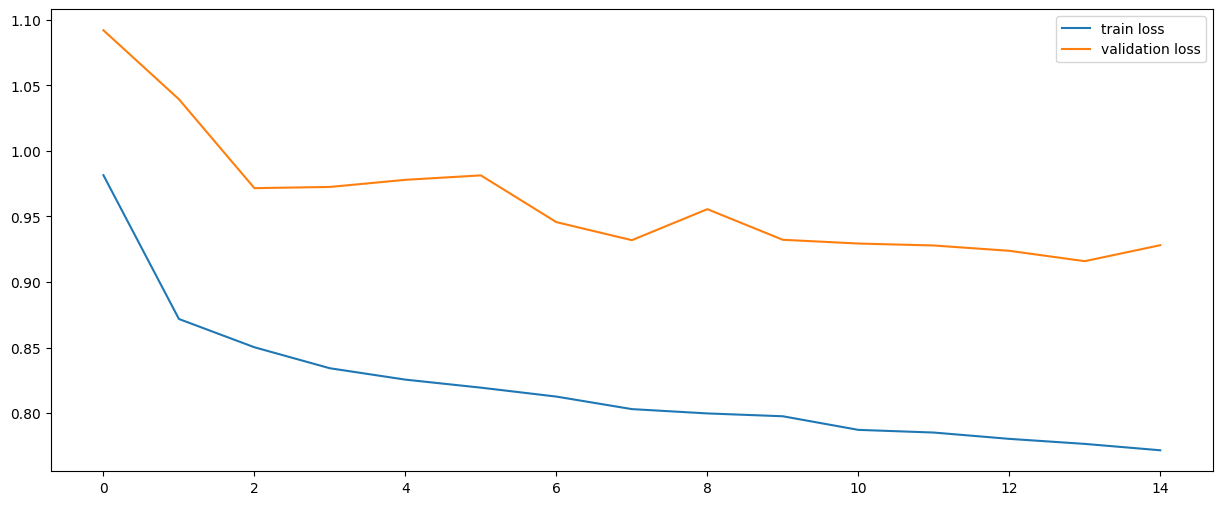

In [14]:
plt.figure(figsize=(15,6))
plt.plot(train_losses, label='train loss')
plt.plot(val_losses, label='validation loss')
plt.legend()

# Model Testing

In [15]:
model = deeplob(y_len = dataset_train.num_classes)
model.load_state_dict(
    torch.load(
        "best_val_featureengmodel_pytorch.pt",
        map_location=device
    )
)
model = model.to(device)
model.eval()

n_correct = 0
n_total = 0

with torch.no_grad():

    for inputs, targets in test_loader:

        inputs = inputs.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        outputs = model(inputs)

        predictions = outputs.argmax(dim=1)

        n_correct += (
            predictions == targets
        ).sum().item()

        n_total += targets.size(0)

test_acc = n_correct / n_total

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.7453


In [16]:
# model = torch.load('best_val_model_pytorch')
all_targets = []
all_predictions = []

for inputs, targets in test_loader:
    # Move to GPU
    inputs, targets = inputs.to(device, dtype=torch.float), targets.to(device, dtype=torch.int64)

    # Forward pass
    outputs = model(inputs)

    # Get prediction
    # torch.max returns both max and argmax
    _, predictions = torch.max(outputs, 1)

    all_targets.append(targets.cpu().numpy())
    all_predictions.append(predictions.cpu().numpy())

all_targets = np.concatenate(all_targets)
all_predictions = np.concatenate(all_predictions)

In [17]:
print('accuracy_score:', accuracy_score(all_targets, all_predictions))
print(classification_report(all_targets, all_predictions, digits=4))

accuracy_score: 0.7452665839827367
              precision    recall  f1-score   support

           0     0.6857    0.6756    0.6806     38408
           1     0.8065    0.8317    0.8189     65995
           2     0.6884    0.6590    0.6734     35084

    accuracy                         0.7453    139487
   macro avg     0.7268    0.7221    0.7243    139487
weighted avg     0.7435    0.7453    0.7442    139487

